In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error,r2_score,mean_squared_error
from sklearn.tree import plot_tree

In [56]:
df = sns.load_dataset('diamonds')

In [57]:
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [58]:
df.isnull().sum().sort_values(ascending = False)

carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64

In [59]:
# 3. ENCODE INDIVIDUALLY
labelencoder = LabelEncoder()
le_cut = LabelEncoder()
le_clarity = LabelEncoder()
le_color = LabelEncoder()
df['cut'] = le_cut.fit_transform(df['cut'])
df['clarity'] = le_clarity.fit_transform(df['clarity'])
df['color'] = le_color.fit_transform(df['color'])
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,2,1,3,61.5,55.0,326,3.95,3.98,2.43
1,0.21,3,1,2,59.8,61.0,326,3.89,3.84,2.31
2,0.23,1,1,4,56.9,65.0,327,4.05,4.07,2.31
3,0.29,3,5,5,62.4,58.0,334,4.20,4.23,2.63
4,0.31,1,6,3,63.3,58.0,335,4.34,4.35,2.75


In [60]:
X = df.drop('price',axis=1)
y = df.price

In [61]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size= 0.2, random_state=40)
modelregresssor = DecisionTreeRegressor(max_depth=4)


In [62]:
modelregresssor.fit(X_train,y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [63]:
regressor_train_score = modelregresssor.score(X_train,y_train)
regressor_test_score = modelregresssor.score(X_test,y_test)
print("The train score of Decision Tree Regressor model is : ",regressor_train_score)
print("The test score of Decision Tree Regressor model is ",regressor_test_score)

The train score of Decision Tree Regressor model is :  0.9077227425067055
The test score of Decision Tree Regressor model is  0.9043888965399116


In [64]:
y_pred = modelregresssor.predict(X_test)

In [65]:

print("R 2 score : ", r2_score(y_test,y_pred))
print("Mean absolute score : ",mean_absolute_error(y_test,y_pred))
print("The mean sqaured absolut error is : ",np.sqrt(mean_squared_error(y_test,y_pred)))

R 2 score :  0.9043888965399116
Mean absolute score :  688.2521402042674
The mean sqaured absolut error is :  1243.2190260112088


[Text(0.5, 0.9, 'x[0] <= 0.995\nsquared_error = 15852573.11\nsamples = 43152\nvalue = 3925.87'),
 Text(0.25, 0.7, 'x[7] <= 5.525\nsquared_error = 1250735.975\nsamples = 27947\nvalue = 1635.185'),
 Text(0.375, 0.8, 'True  '),
 Text(0.125, 0.5, 'x[7] <= 4.995\nsquared_error = 267632.084\nsamples = 19909\nvalue = 1054.442'),
 Text(0.0625, 0.3, 'x[6] <= 4.625\nsquared_error = 56682.753\nsamples = 14037\nvalue = 788.904'),
 Text(0.03125, 0.1, 'squared_error = 35177.891\nsamples = 9489\nvalue = 701.106'),
 Text(0.09375, 0.1, 'squared_error = 51912.432\nsamples = 4548\nvalue = 972.085'),
 Text(0.1875, 0.3, 'x[3] <= 5.5\nsquared_error = 200417.909\nsamples = 5872\nvalue = 1689.212'),
 Text(0.15625, 0.1, 'squared_error = 140890.369\nsamples = 4844\nvalue = 1587.543'),
 Text(0.21875, 0.1, 'squared_error = 202702.789\nsamples = 1028\nvalue = 2168.28'),
 Text(0.375, 0.5, 'x[0] <= 0.855\nsquared_error = 781351.904\nsamples = 8038\nvalue = 3073.602'),
 Text(0.3125, 0.3, 'x[3] <= 3.5\nsquared_error =

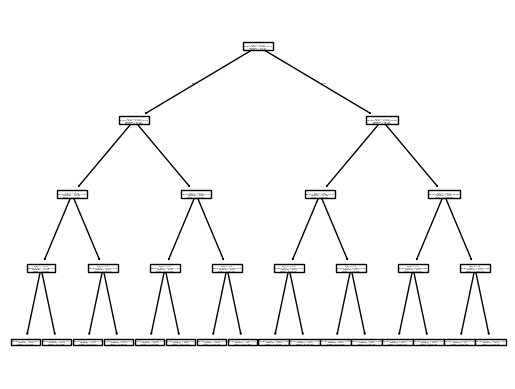

In [66]:
plot_tree(modelregresssor)


In [67]:
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,2,1,3,61.5,55.0,326,3.95,3.98,2.43
1,0.21,3,1,2,59.8,61.0,326,3.89,3.84,2.31
2,0.23,1,1,4,56.9,65.0,327,4.05,4.07,2.31
3,0.29,3,5,5,62.4,58.0,334,4.20,4.23,2.63
4,0.31,1,6,3,63.3,58.0,335,4.34,4.35,2.75


In [68]:
# df['cut'] = labelencoder.inverse_transform(df['cut'])
# df['clarity'] = labelencoder.inverse_transform(df['clarity'])
# df['color'] = labelencoder.inverse_transform(df['color'])
# df.head()


# 4. DECODE INDIVIDUALLY (Run this cell ONLY ONCE)
df['cut'] = le_cut.inverse_transform(df['cut'])
df['clarity'] = le_clarity.inverse_transform(df['clarity'])
df['color'] = le_color.inverse_transform(df['color'])

# print("\nDecoded Data:")
# print(df[['cut', 'clarity', 'color']].head())
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


Decision Tree Classifier Algorithm

In [74]:
# 3. ENCODE INDIVIDUALLY
labelencoder = LabelEncoder()
le_cut = LabelEncoder()
le_clarity = LabelEncoder()
le_color = LabelEncoder()
df['cut'] = le_cut.fit_transform(df['cut'])
df['clarity'] = le_clarity.fit_transform(df['clarity'])
df['color'] = le_color.fit_transform(df['color'])
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,2,1,3,61.5,55.0,326,3.95,3.98,2.43
1,0.21,3,1,2,59.8,61.0,326,3.89,3.84,2.31
2,0.23,1,1,4,56.9,65.0,327,4.05,4.07,2.31
3,0.29,3,5,5,62.4,58.0,334,4.20,4.23,2.63
4,0.31,1,6,3,63.3,58.0,335,4.34,4.35,2.75


In [75]:
X = df.drop('color',axis=1)
y = df.color

In [76]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size= 0.2, random_state=30)
modelclassifier = DecisionTreeClassifier(max_depth=4)

In [78]:
modelclassifier.fit(X_train,y_train)
print("The model classifier train score is : ",modelclassifier.score(X_test,y_test))
print("The model classifier test score is : ",modelclassifier.score(X_test,y_test))
y_pred = modelclassifier.predict(X_test)


The model classifier train score is :  0.2435113088616982
The model classifier test score is :  0.2435113088616982


In [81]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
print("The Accuracy score of this model is : ",accuracy_score(y_test,y_pred))
print("The Recall score of this model is : ", recall_score(y_test,y_pred,average="micro"))
print("The Precision score of this model is : ",precision_score(y_test,y_pred,average="micro"))
print("The f1 score of this model is : ",f1_score(y_test,y_pred,average="micro"))

The Accuracy score of this model is :  0.2435113088616982
The Recall score of this model is :  0.2435113088616982
The Precision score of this model is :  0.2435113088616982
The f1 score of this model is :  0.2435113088616982


[Text(0.5, 0.9, 'x[8] <= 4.105\ngini = 0.84\nsamples = 43152\nvalue = [5388, 7868, 7642, 9032, 6609, 4382, 2231]'),
 Text(0.25, 0.7, 'x[5] <= 5914.5\ngini = 0.829\nsamples = 34111\nvalue = [4892, 7116, 6577, 7222, 4596, 2622, 1086]'),
 Text(0.375, 0.8, 'True  '),
 Text(0.125, 0.5, 'x[0] <= 0.865\ngini = 0.832\nsamples = 31930\nvalue = [4574, 6698, 6001, 6456, 4504, 2611, 1086]'),
 Text(0.0625, 0.3, 'x[5] <= 581.5\ngini = 0.826\nsamples = 25633\nvalue = [3871.0, 5734.0, 4878.0, 5371.0, 3136.0, 1909.0, 734.0]'),
 Text(0.03125, 0.1, 'gini = 0.841\nsamples = 2934\nvalue = [305, 489, 345, 516, 620, 488, 171]'),
 Text(0.09375, 0.1, 'gini = 0.819\nsamples = 22699\nvalue = [3566, 5245, 4533, 4855, 2516, 1421, 563]'),
 Text(0.1875, 0.3, 'x[2] <= 3.5\ngini = 0.84\nsamples = 6297\nvalue = [703, 964, 1123, 1085, 1368, 702, 352]'),
 Text(0.15625, 0.1, 'gini = 0.837\nsamples = 4915\nvalue = [667.0, 863.0, 1000.0, 828.0, 911.0, 435.0, 211.0]'),
 Text(0.21875, 0.1, 'gini = 0.794\nsamples = 1382\nvalue

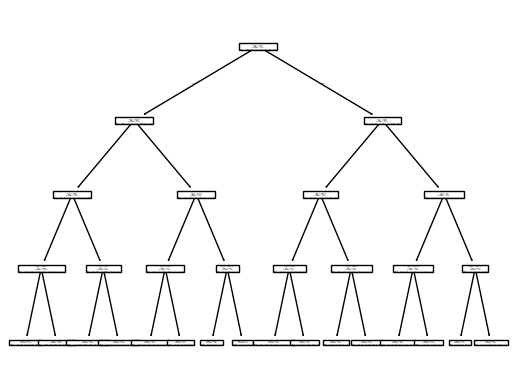

In [82]:
plot_tree(modelclassifier)

In [83]:
# 4. DECODE INDIVIDUALLY (Run this cell ONLY ONCE)
df['cut'] = le_cut.inverse_transform(df['cut'])
df['clarity'] = le_clarity.inverse_transform(df['clarity'])
df['color'] = le_color.inverse_transform(df['color'])

df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
